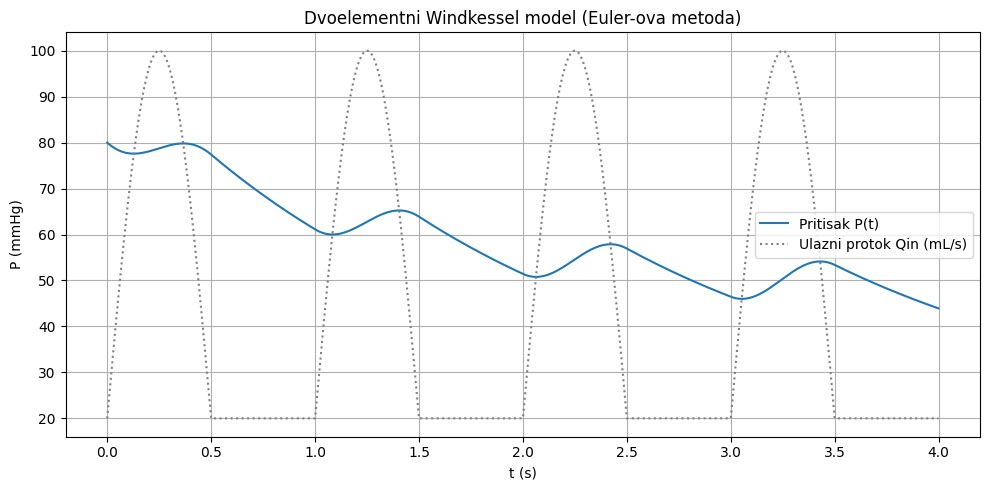

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
C  = 1.5      # mL/mmHg
R  = 1.0      # mmHg*s/mL
f  = 1.0      # Hz (srcani ritam ~60/min)
A  = 80.0     # amplituda protoka (mL/s)
Q0 = 20.0     # bazni protok (mL/s)
dt = 0.001    # vremenski korak (s)
tmax = 4.0    # trajanje simulacije (s)

t = np.arange(0, tmax, dt)
Qin = Q0 + A * np.maximum(0, np.sin(2 * np.pi * f * t))

# Euler-ova metoda
P = np.zeros_like(t)
P[0] = 80.0   # pocetni uslov P(0) = 80 mmHg

for i in range(1, len(t)):
    dPdt = (1/C) * (Qin[i-1] - P[i-1]/R)
    P[i] = P[i-1] + dPdt * dt

# Crtanje
plt.figure(figsize=(10, 5))
plt.plot(t, P, label="Pritisak P(t)", color="tab:blue")
plt.plot(t, Qin, ':', label="Ulazni protok Qin (mL/s)", color="gray")
plt.xlabel("t (s)")
plt.ylabel("P (mmHg)")
plt.title("Dvoelementni Windkessel model (Euler-ova metoda)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

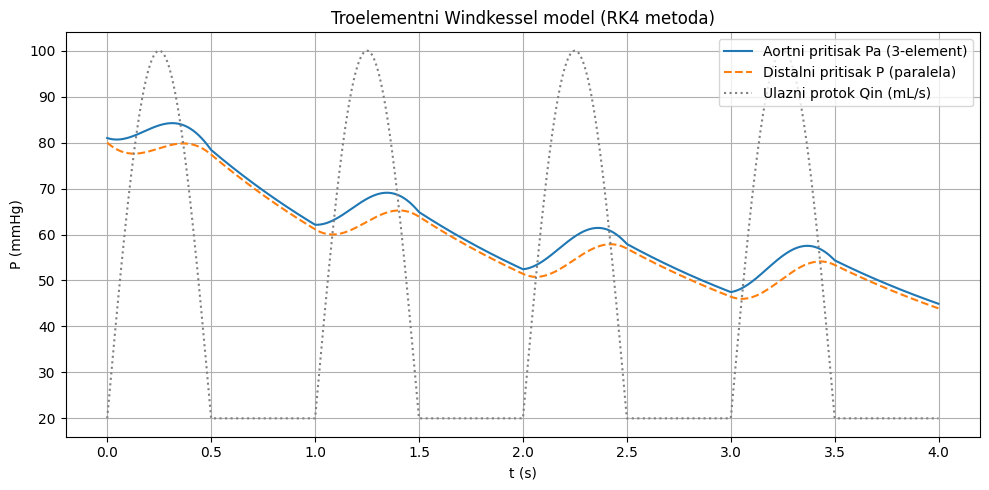

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
C  = 1.5      # mL/mmHg
R2 = 1.0      # mmHg*s/mL (periferni otpor)
R1 = 0.05     # mmHg*s/mL (karakteristicna impedansa)
f  = 1.0      # Hz
A  = 80.0     # mL/s
Q0 = 20.0     # mL/s
dt = 0.001
tmax = 4.0

t = np.arange(0, tmax, dt)
Qin = Q0 + A * np.maximum(0, np.sin(2*np.pi*f*t))

def dPdt(P, Qin_t):
    return (Qin_t - P / R2) / C

# RK4 integrator
P = np.zeros_like(t)
P[0] = 80.0

for i in range(len(t)-1):
    Pi = P[i]
    q  = Qin[i]
    k1 = dPdt(Pi, q)
    k2 = dPdt(Pi + 0.5*dt*k1, q)
    k3 = dPdt(Pi + 0.5*dt*k2, q)
    k4 = dPdt(Pi + dt*k3, q)
    P[i+1] = Pi + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0

# Mereni aortni pritisak
Pa = P + R1 * Qin

# Crtanje
plt.figure(figsize=(10, 5))
plt.plot(t, Pa, label="Aortni pritisak Pa (3-element)", color="tab:blue")
plt.plot(t, P, '--', label="Distalni pritisak P (paralela)", color="tab:orange")
plt.plot(t, Qin, ':', label="Ulazni protok Qin (mL/s)", color="gray")
plt.xlabel("t (s)")
plt.ylabel("P (mmHg)")
plt.title("Troelementni Windkessel model (RK4 metoda)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

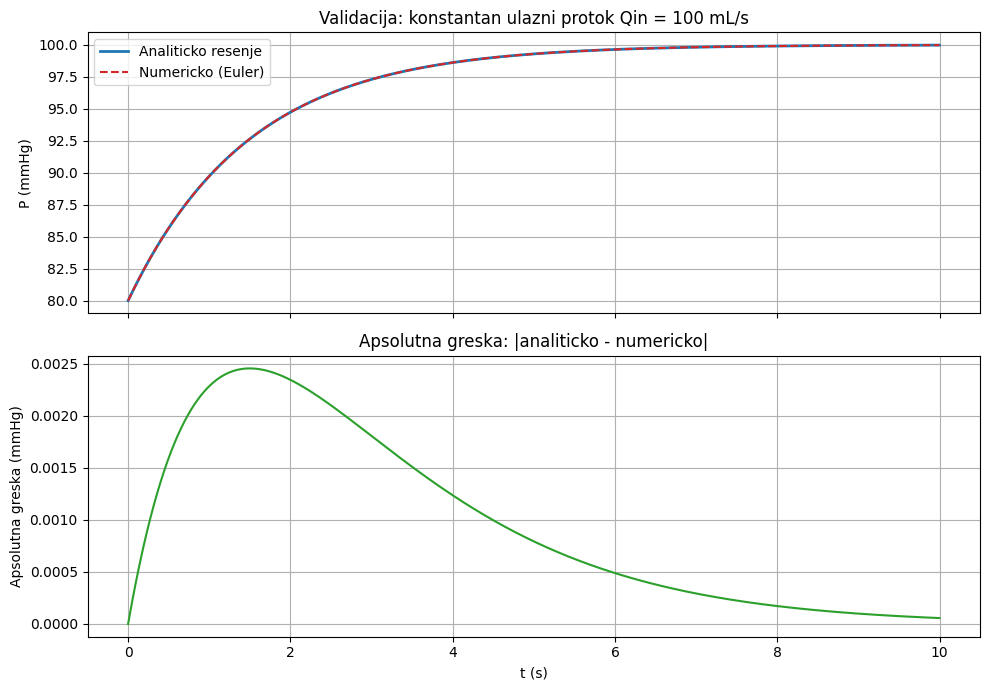

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
C  = 1.5      # mL/mmHg
R  = 1.0      # mmHg*s/mL
dt = 0.001
tmax = 10.0   # duze trajanje da se vidi priblizavanje stacionarnom stanju
t = np.arange(0, tmax, dt)

Qin_const = 100.0   # mL/s (konstantan protok)
P0 = 80.0           # mmHg

# Analiticko resenje
P_steady = Qin_const * R          # = 100 mmHg
tau = R * C                       # vremenska konstanta = 1.5 s
P_analytical = P_steady + (P0 - P_steady) * np.exp(-t / tau)

# Numericko resenje (Euler)
P_euler = np.zeros_like(t)
P_euler[0] = P0
for i in range(1, len(t)):
    dPdt = (1/C) * (Qin_const - P_euler[i-1]/R)
    P_euler[i] = P_euler[i-1] + dPdt * dt

# Greska
error = np.abs(P_analytical - P_euler)

# Crtanje (dva panela)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(t, P_analytical, label="Analiticko resenje", color="tab:blue", linewidth=2)
ax1.plot(t, P_euler, '--', label="Numericko (Euler)", color="tab:red")
ax1.set_ylabel("P (mmHg)")
ax1.set_title("Validacija: konstantan ulazni protok Qin = 100 mL/s")
ax1.legend()
ax1.grid(True)

ax2.plot(t, error, color="tab:green")
ax2.set_xlabel("t (s)")
ax2.set_ylabel("Apsolutna greska (mmHg)")
ax2.set_title("Apsolutna greska: |analiticko - numericko|")
ax2.grid(True)

plt.tight_layout()
plt.show()

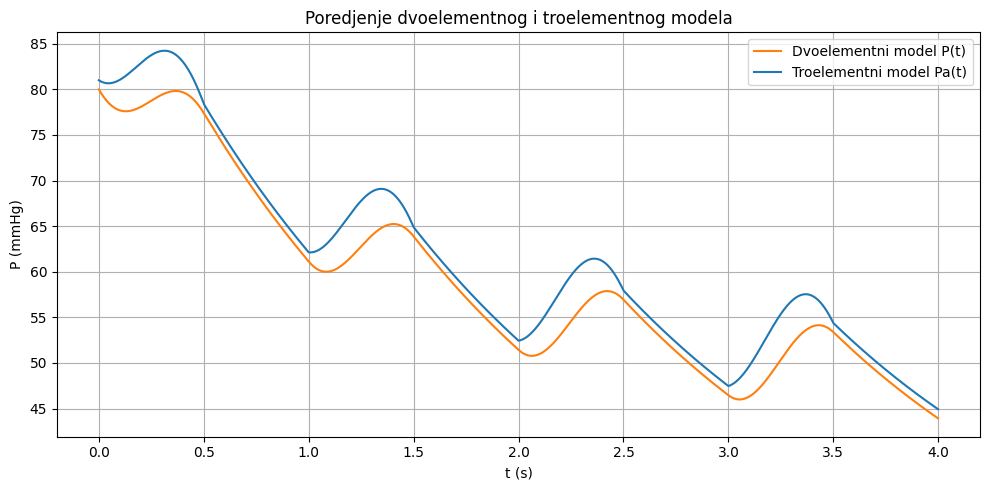

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Zajednicki parametri
C  = 1.5
R  = 1.0      # 2-elem: periferni otpor
R2 = 1.0      # 3-elem: periferni otpor
R1 = 0.05     # 3-elem: karakteristicna impedansa
f  = 1.0
A  = 80.0
Q0 = 20.0
dt = 0.001
tmax = 4.0

t = np.arange(0, tmax, dt)
Qin = Q0 + A * np.maximum(0, np.sin(2*np.pi*f*t))

# --- Dvoelementni (Euler) ---
P2 = np.zeros_like(t)
P2[0] = 80.0
for i in range(1, len(t)):
    dPdt = (1/C) * (Qin[i-1] - P2[i-1]/R)
    P2[i] = P2[i-1] + dPdt * dt

# --- Troelementni (RK4) ---
def dPdt3(P, Qin_t):
    return (Qin_t - P / R2) / C

P3 = np.zeros_like(t)
P3[0] = 80.0
for i in range(len(t)-1):
    Pi = P3[i]
    q  = Qin[i]
    k1 = dPdt3(Pi, q)
    k2 = dPdt3(Pi + 0.5*dt*k1, q)
    k3 = dPdt3(Pi + 0.5*dt*k2, q)
    k4 = dPdt3(Pi + dt*k3, q)
    P3[i+1] = Pi + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0
Pa3 = P3 + R1 * Qin   # aortni pritisak 3-elem

# Crtanje
plt.figure(figsize=(10, 5))
plt.plot(t, P2, label="Dvoelementni model P(t)", color="tab:orange")
plt.plot(t, Pa3, label="Troelementni model Pa(t)", color="tab:blue")
plt.xlabel("t (s)")
plt.ylabel("P (mmHg)")
plt.title("Poredjenje dvoelementnog i troelementnog modela")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

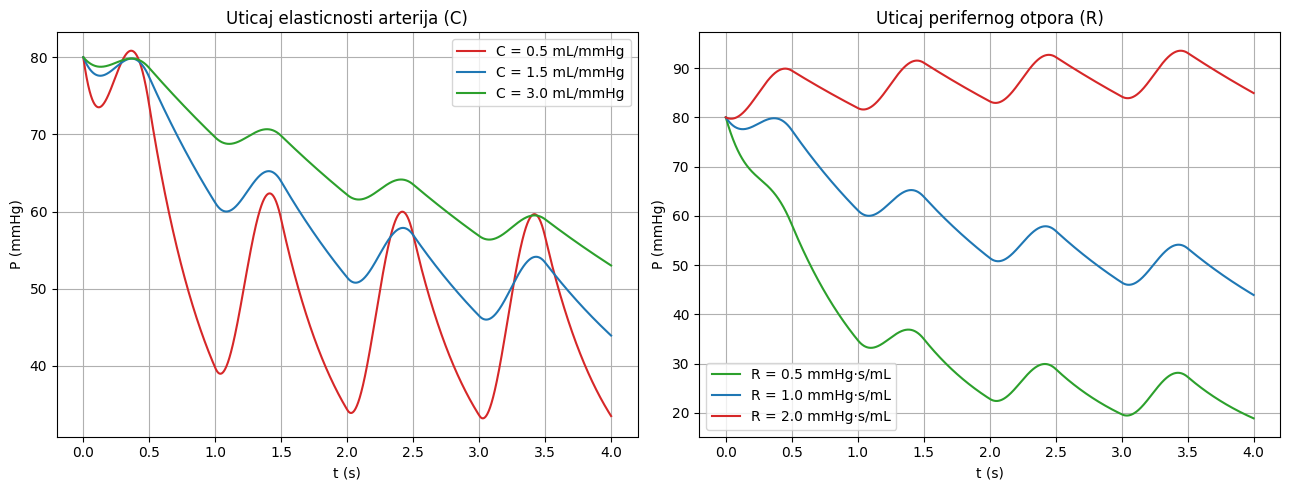

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Bazni parametri
f  = 1.0
A  = 80.0
Q0 = 20.0
dt = 0.001
tmax = 4.0
t = np.arange(0, tmax, dt)
Qin = Q0 + A * np.maximum(0, np.sin(2*np.pi*f*t))

def simuliraj(R, C):
    P = np.zeros_like(t)
    P[0] = 80.0
    for i in range(1, len(t)):
        dPdt = (1/C) * (Qin[i-1] - P[i-1]/R)
        P[i] = P[i-1] + dPdt * dt
    return P

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Levo: uticaj elasticnosti C (R fiksno = 1.0) ---
for C_val, boja in [(0.5, "tab:red"), (1.5, "tab:blue"), (3.0, "tab:green")]:
    P = simuliraj(R=1.0, C=C_val)
    ax1.plot(t, P, label=f"C = {C_val} mL/mmHg", color=boja)
ax1.set_xlabel("t (s)")
ax1.set_ylabel("P (mmHg)")
ax1.set_title("Uticaj elasticnosti arterija (C)")
ax1.legend()
ax1.grid(True)

# --- Desno: uticaj perifernog otpora R (C fiksno = 1.5) ---
for R_val, boja in [(0.5, "tab:green"), (1.0, "tab:blue"), (2.0, "tab:red")]:
    P = simuliraj(R=R_val, C=1.5)
    ax2.plot(t, P, label=f"R = {R_val} mmHg·s/mL", color=boja)
ax2.set_xlabel("t (s)")
ax2.set_ylabel("P (mmHg)")
ax2.set_title("Uticaj perifernog otpora (R)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()